Importing all necessary libraries

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

### Declaring all visual styles and colours to be used

In [6]:
plt.rcParams.update({
    'figure.facecolor': "white",
    'axes.facecolor': "#f8fdf9",
    "axes.grid" : True,
    "grid.color": "#ddeee3",
    "grid.linewidth": 0.6,
    "axes.spines.right": False,
    'axes.spines.top': False,
    'font.size': 11
 })


In [60]:
#Using One Acre Fund Theme as Colour Palette
c = {
    'ctrl': '#8da899',
    'treat': '#52b788',
    'best' : '#1a3d2b',
    'warn' : '#e9a825',
    'fail' : '#c0392b',
    'bg' : '#f0faf3'
}
pd.set_option('display.float_format', "{:.4f}". format)
pd.set_option('display.max_columns', 30)
print('Everything validated')

Everything validated


## LOADING DATA

In [19]:
data = pd.read_csv('OAF/Data Analyst and Automation Specialist Exercise R1.csv')
data.head()

,Unnamed: 0,DistrictID,SiteID,GroupID,ClientID,TotalEnrolledSeasons,GroupLeader,Treatment,Treated,MainTreatment,MentionedDeadline,RemainingAmount,LastReminder,TotalCredit,TotalPaidNov20,Qualified2017,QualifiedBeforeTrial,Qualified,PrePaid,QualifiedDec15
0,1,5,196,5896,1.0000,3,0,T4,1,T4,1.0000,1.0000,0.0000,8630,0.0000,0,0,1,1,0
1,2,5,199,5970,2.0000,1,0,control,0,0,NaN,NaN,NaN,5785,0.0000,0,0,0,0,0
2,3,16,605,17799,3.0000,1,0,T5S,1,T5,0.0000,1.0000,0.0000,10285,1000.0000,0,1,1,1,1
3,4,32,1321,38728,4.0000,1,0,control,0,0,NaN,NaN,NaN,13205,0.0000,0,0,1,1,1
4,5,37,1485,43320,5.0000,1,0,control,0,0,NaN,NaN,NaN,13530,1000.0000,0,1,1,1,1


In [26]:
new_data = data.drop(columns =['Unnamed: 0']).copy()

In [28]:
#Casting ClientID to integer since it is in float
assert(new_data['ClientID'] ==new_data['ClientID'].round().all(), 'Fractional ClientIDs Found')
new_data['ClientID'] =new_data['ClientID'].astype(int)

print(f"Rows : {len(new_data):,}")
print(f"Columns : {new_data.shape[1]}")
new_data.head()

Rows : 462,885
Columns : 19


,DistrictID,SiteID,GroupID,ClientID,TotalEnrolledSeasons,GroupLeader,Treatment,Treated,MainTreatment,MentionedDeadline,RemainingAmount,LastReminder,TotalCredit,TotalPaidNov20,Qualified2017,QualifiedBeforeTrial,Qualified,PrePaid,QualifiedDec15
0,5,196,5896,1,3,0,T4,1,T4,1.0000,1.0000,0.0000,8630,0.0000,0,0,1,1,0
1,5,199,5970,2,1,0,control,0,0,NaN,NaN,NaN,5785,0.0000,0,0,0,0,0
2,16,605,17799,3,1,0,T5S,1,T5,0.0000,1.0000,0.0000,10285,1000.0000,0,1,1,1,1
3,32,1321,38728,4,1,0,control,0,0,NaN,NaN,NaN,13205,0.0000,0,0,1,1,1
4,37,1485,43320,5,1,0,control,0,0,NaN,NaN,NaN,13530,1000.0000,0,1,1,1,1


In [30]:
#Checking Data types
print(new_data.dtypes)

DistrictID                int64
SiteID                    int64
GroupID                   int64
ClientID                  int64
TotalEnrolledSeasons      int64
GroupLeader               int64
Treatment                object
Treated                   int64
MainTreatment            object
MentionedDeadline       float64
RemainingAmount         float64
LastReminder            float64
TotalCredit               int64
TotalPaidNov20          float64
Qualified2017             int64
QualifiedBeforeTrial      int64
Qualified                 int64
PrePaid                   int64
QualifiedDec15            int64
dtype: object


# DATA CLEANING

In [32]:
multi_farmers = new_data['ClientID'].duplicated().sum()
dup_rows = new_data.duplicated().sum()

if multi_farmers !=0 or dup_rows !=0:
    print(f"Duplicate ClientIDs : {multi_farmers}")
    print(f"Duplicate full rows : {dup_rows}")
else:
    print("Everything Verified, no duplicates!. You can proceed to next level")

Everything Verified, no duplicates!. You can proceed to next level


### Missing Values Syndicates

In [33]:
new_data.describe()

,DistrictID,SiteID,GroupID,ClientID,TotalEnrolledSeasons,GroupLeader,Treated,MentionedDeadline,RemainingAmount,LastReminder,TotalCredit,TotalPaidNov20,Qualified2017,QualifiedBeforeTrial,Qualified,PrePaid,QualifiedDec15
count,462885.0000,462885.0000,462885.0000,462885.0000,462885.0000,462885.0000,462885.0000,269978.0000,269978.0000,308641.0000,462885.0000,462885.0000,462885.0000,462885.0000,462885.0000,462885.0000,462885.0000
mean,19.2027,781.1701,22919.2738,231443.0000,1.8517,0.0988,0.6668,0.5003,0.5000,0.4999,9997.0770,457.3258,0.1666,0.4120,0.7907,0.7982,0.6995
std,10.8954,462.0294,13372.5833,133623.5340,1.3865,0.2984,0.4714,0.5000,0.5000,0.5000,4509.3864,1014.9760,0.3726,0.4922,0.4068,0.4013,0.4585
min,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,9.0000,368.0000,11020.0000,115722.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,6250.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000
50%,20.0000,787.0000,22857.0000,231443.0000,1.0000,0.0000,1.0000,1.0000,1.0000,0.0000,9475.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000
75%,27.0000,1175.0000,34322.0000,347164.0000,2.0000,0.0000,1.0000,1.0000,1.0000,1.0000,12685.0000,525.0000,0.0000,1.0000,1.0000,1.0000,1.0000
max,38.0000,1576.0000,45826.0000,462885.0000,14.0000,1.0000,1.0000,1.0000,1.0000,1.0000,41490.0000,30765.0000,1.0000,1.0000,1.0000,1.0000,1.0000


Columns MentionedDeadline, RemainingAmount and LastReminder all contains missing data but these are structurally right
So we validate the structure explicitly

In [34]:
missing_data = (new_data.isnull().sum())
missing_data

DistrictID                   0
SiteID                       0
GroupID                      0
ClientID                     0
TotalEnrolledSeasons         0
GroupLeader                  0
Treatment                    0
Treated                      0
MainTreatment                0
MentionedDeadline       192907
RemainingAmount         192907
LastReminder            154244
TotalCredit                  0
TotalPaidNov20               0
Qualified2017                0
QualifiedBeforeTrial         0
Qualified                    0
PrePaid                      0
QualifiedDec15               0
dtype: int64

From the result, it shows that Clients that with MentionedDeadline has 192907 missing data, RemainingAmount has same missing
data while lastRemainder has 154244 which are structurally right due to the type of data we are working with

##### Asserting that they are structurally right

In [49]:
n_control = (new_data['Treated']==0).sum()
n_T6 = (new_data['MainTreatment']=='T6').sum()
expected_missing = n_control + n_T6
print(f"n_control                      :   {n_control:,}")
print(f"n_T6                           :   {n_T6:,}")
print(f"Expected NaN (Ctrl + T6)       :   {expected_missing:,}")
print(f"Actual NaN MentionedDeadline   :   {missing_data['MentionedDeadline']:,}")

#Assertion
if(missing_data['MentionedDeadline']==expected_missing 
   and missing_data["RemainingAmount"] ==expected_missing):
    print('NaN in cross-Randomization columns =Control +T6 is structurally correct')
else:
    if missing_data['MentionedDeadline']!=expected_missing:
        print(f'Unexpected NaN pattern in MentionedDeadline:'
             f"got {missing['MentionedDeadline']:,},"
             f"expected {expected_missing:,}"
             )
    if missing_data['RemainingAmount'] != expected_missing:
        print(
        f"Unexpected NaN pattern in RemainingAmount: "
        f"got {missing_data['RemainingAmount']:,},"
        f"expected {expected_missing:,}"
        )

n_control                      :   154,244
n_T6                           :   38,663
Expected NaN (Ctrl + T6)       :   192,907
Actual NaN MentionedDeadline   :   192,907
NaN in cross-Randomization columns =Control +T6 is structurally correct


From the Results from Asserting the errors whether they are structurally correct or not,
It can be seen that the control i.e. the group that no SMS was sent to and the Tier 6 (T_6) which only talks to their group leader both formed our
Expected NaN group because they both didn't receive SMS. The summation of the two numbers were equal to the summation
of NaN in MentionedDeadline (192,907). So The NaN in Control (154,244) and T6 (38,663) are structually correct

### Treatment Arm Sizes

In [50]:
#Getting counts of Sample size in each Treatment
arm_counts = new_data['MainTreatment'].value_counts().sort_index()
arm_counts

MainTreatment
0     154244
T1     38627
T2     77072
T3     38361
T4     38579
T5     77339
T6     38663
Name: count, dtype: int64

In [52]:
#Getting Percentage that each group represent
arm_percentage = (arm_counts/len(new_data)*100).round(1)
arm_percentage

MainTreatment
0    33.3000
T1    8.3000
T2   16.7000
T3    8.3000
T4    8.3000
T5   16.7000
T6    8.4000
Name: count, dtype: float64

In [55]:
#Turning both to Table
summary = pd.DataFrame({'Counts': arm_counts, 'Percentage %': arm_percentage})
summary

,Counts,Percentage %
MainTreatment,,
0,154244,33.3000
T1,38627,8.3000
T2,77072,16.7000
T3,38361,8.3000
T4,38579,8.3000
T5,77339,16.7000
T6,38663,8.4000


From the Distribution result of the Data, it shows that 33.3% belong to group 0, 8.3% belongs to T1, 16.7% were in T2
8.3% are also in T3, and T4 each. T5 size was 16.7% while 8.4% of the total population were in Group T6.

In [56]:
#Finding the ratio of the Treated samples to untreated samples
ratio = (new_data['Treated']==1).sum()/(new_data['Treated']==0).sum()
print(f"\nControl   : Treated = 1 : {ratio:.2f}    (expected = 1:2)")


Control   : Treated = 1 : 2.00    (expected = 1:2)


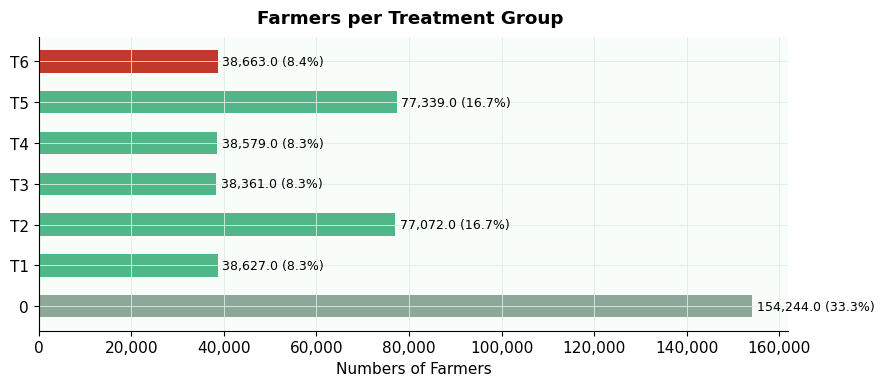

In [62]:
#Representing data in a plot
fig, ax = plt.subplots(figsize=(9,4))
colors = [c['ctrl'] if t =='0' else c['fail'] if t=='T6' else c['treat']
          for t in summary.index]
bars =ax.barh(summary.index, summary['Counts'], color=colors, height=0.55, edgecolor='none')
ax.set_xlabel('Numbers of Farmers')
ax.set_title("Farmers per Treatment Group ", fontweight = 'bold', pad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, (_, row) in zip(bars, summary.iterrows()):
    ax.text(bar.get_width() +1000, bar.get_y() + bar.get_height()/2,
           f"{row['Counts']:,} ({row['Percentage %']}%)", va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig1 Distribution by Treatment.png', dpi=150, bbox_inches='tight')
plt.show()

## Verification of Treatment by Covariance balancing

In [65]:
#Mapping of columns to the statistical type
balance_cols = {
    'TotalCredit': 'continous',
    'TotalEnrolledSeasons': 'continous',
    'TotalPaidNov20': 'continous',
    'GroupLeader': 'binary',
    'Qualified2017': 'binary',
    'QualifiedBeforeTrial': 'binary',
}
#Covariate Means
balance_means =new_data.groupby("MainTreatment")[list(balance_cols.keys())].mean()
balance_means.to_csv('Covariate means by Treatment Group')
balance_means

,TotalCredit,TotalEnrolledSeasons,TotalPaidNov20,GroupLeader,Qualified2017,QualifiedBeforeTrial
MainTreatment,,,,,,
0,9995.3781,1.8513,457.5206,0.0988,0.1667,0.4119
T1,9976.4978,1.8512,455.9551,0.0967,0.1681,0.4129
T2,10010.3279,1.8519,456.9119,0.0994,0.1659,0.4116
T3,10001.0606,1.8434,447.8157,0.0985,0.1658,0.4069
T4,9996.6444,1.8535,458.9029,0.1015,0.1665,0.4140
T5,10008.8492,1.8549,460.5058,0.0979,0.1662,0.4139
T6,9970.9305,1.8537,460.2437,0.0992,0.1681,0.4120


In [67]:
#Omnibus balance tests
for col, kind in balance_cols.items():
    groups = [g[col].values for _, g in new_data.groupby("MainTreatment")]
    if kind == 'continous':
        stat, p=stats.f_oneway(*groups)
        test = "ANOVA F"
    else:
        ct =pd.crosstab(new_data['MainTreatment'], new_data[col])
        stat, p, _, _ =stats.chi2_contingency(ct)
        test = 'Chi-sq '
    flag = ' large sample artefact, check effect size' if p< 0.05 else ""
    print(f' {col:<25} {test}: stat ={stat:8.2f}, p={p:.4f}{flag}')

 TotalCredit               ANOVA F: stat =    0.56, p=0.7639
 TotalEnrolledSeasons      ANOVA F: stat =    0.33, p=0.9238
 TotalPaidNov20            ANOVA F: stat =    0.77, p=0.5923
 GroupLeader               Chi-sq : stat =    6.22, p=0.3995
 Qualified2017             Chi-sq : stat =    1.74, p=0.9421
 QualifiedBeforeTrial      Chi-sq : stat =    6.14, p=0.4072


### Pre-trial Qualifier (Most important decision in this analysis)

In [71]:
#Getting those qualified before trial counts
pre_trial = (new_data['QualifiedBeforeTrial']==1).sum()
#Getting the percentage
pre_trial_percent = (pre_trial/len(new_data) *100).round(1)
print(f"Total number of Qualified clients before Trail is:  {pre_trial} representing {pre_trial_percent}% of the total population")

Total number of Qualified clients before Trail is:  190727 representing 41.2% of the total population


In [72]:
#Since we have the pre_trial, getting inscope data
in_scope = len(new_data) - pre_trial
in_scope

272158

The outcome of the data above shows that before the trial begins, 190,727 clients are already qualified, this
means that we don't have to include them in the study as messaging them has no effect. While In-scope data is 272,158 which is the area of concentration

In [75]:
by_flag =new_data.groupby("QualifiedBeforeTrial")['Qualified'].mean()
print(f"Qualification rate - pre-trial Qualifiers : {by_flag[1]:.1%}   (near ceiling - expected)")
print(f"Qualifification rate - in-scope farmers : {by_flag[0]:.1%} (true baseline for analysis)")

Qualification rate - pre-trial Qualifiers : 99.4%   (near ceiling - expected)
Qualifification rate - in-scope farmers : 64.8% (true baseline for analysis)


#### Creating Primary Data or Subset Data

In [79]:
df_scope = new_data[new_data['QualifiedBeforeTrial']==0]
df_scope.head()

,DistrictID,SiteID,GroupID,ClientID,TotalEnrolledSeasons,GroupLeader,Treatment,Treated,MainTreatment,MentionedDeadline,RemainingAmount,LastReminder,TotalCredit,TotalPaidNov20,Qualified2017,QualifiedBeforeTrial,Qualified,PrePaid,QualifiedDec15
0,5,196,5896,1,3,0,T4,1,T4,1.0000,1.0000,0.0000,8630,0.0000,0,0,1,1,0
1,5,199,5970,2,1,0,control,0,0,NaN,NaN,NaN,5785,0.0000,0,0,0,0,0
3,32,1321,38728,4,1,0,control,0,0,NaN,NaN,NaN,13205,0.0000,0,0,1,1,1
7,4,130,4117,8,1,0,control,0,0,NaN,NaN,NaN,13675,0.0000,0,0,0,0,0
9,3,115,3771,10,1,0,T6,1,T6,NaN,NaN,0.0000,4080,0.0000,0,0,1,1,0


In [81]:
#Adding Engineered feature for further analysis
df_scope["credit_q"]=pd.qcut(df_scope['TotalCredit'],4, labels= ['Q1 Low', 'Q2', 'Q3', 'Q4 High'])
df_scope['season_group']=df_scope['TotalEnrolledSeasons'].apply(
    lambda x: "New (1)" if x==1 else ("Mid (2-3)" if x <=3 else "Veteran (4+)"))


In [80]:
df_scope.to_csv('Inscope Data.csv')

In [82]:
df_scope

,DistrictID,SiteID,GroupID,ClientID,TotalEnrolledSeasons,GroupLeader,Treatment,Treated,MainTreatment,MentionedDeadline,RemainingAmount,LastReminder,TotalCredit,TotalPaidNov20,Qualified2017,QualifiedBeforeTrial,Qualified,PrePaid,QualifiedDec15,credit_q,season_group
0,5,196,5896,1,3,0,T4,1,T4,1.0000,1.0000,0.0000,8630,0.0000,0,0,1,1,0,Q3,Mid (2-3)
1,5,199,5970,2,1,0,control,0,0,NaN,NaN,NaN,5785,0.0000,0,0,0,0,0,Q1 Low,New (1)
3,32,1321,38728,4,1,0,control,0,0,NaN,NaN,NaN,13205,0.0000,0,0,1,1,1,Q4 High,New (1)
7,4,130,4117,8,1,0,control,0,0,NaN,NaN,NaN,13675,0.0000,0,0,0,0,0,Q4 High,New (1)
9,3,115,3771,10,1,0,T6,1,T6,NaN,NaN,0.0000,4080,0.0000,0,0,1,1,0,Q1 Low,New (1)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
462878,36,1471,42921,462879,1,0,T3L,1,T3,0.0000,0.0000,1.0000,7175,0.0000,0,0,1,1,1,Q2,New (1)
462879,6,207,6230,462880,1,0,T2GG,1,T2,1.0000,1.0000,1.0000,4080,0.0000,0,0,1,1,0,Q1 Low,New (1)
462880,35,1406,41215,462881,2,0,T1,1,T1,1.0000,0.0000,0.0000,6585,0.0000,0,0,1,1,1,Q2,Mid (2-3)
462881,30,1292,37907,462882,3,0,control,0,0,NaN,NaN,NaN,7470,0.0000,0,0,1,1,0,Q2,Mid (2-3)


In [83]:
df_scope.to_csv('Inscope Data + Engineered Features')

### Raw Outcome before Modeling

In [88]:
rates_full_data =new_data.groupby('MainTreatment')[['Qualified', 'QualifiedDec15']].mean()
rates_scope = df_scope.groupby('MainTreatment')[['Qualified', 'QualifiedDec15']].mean()

rates_full_data


,Qualified,QualifiedDec15
MainTreatment,,
0,0.7840,0.6925
T1,0.7958,0.7038
T2,0.7963,0.7043
T3,0.7928,0.7043
T4,0.7922,0.6994
T5,0.7964,0.7074
T6,0.7861,0.6935


In [87]:
rates_scope

,Qualified,QualifiedDec15
MainTreatment,,
0,0.6368,0.4771
T1,0.6553,0.4954
T2,0.6576,0.4975
T3,0.6550,0.5014
T4,0.6492,0.4870
T5,0.6562,0.5007
T6,0.6403,0.4787


### Plotting a side by side Bar Chart of Rates Outcome

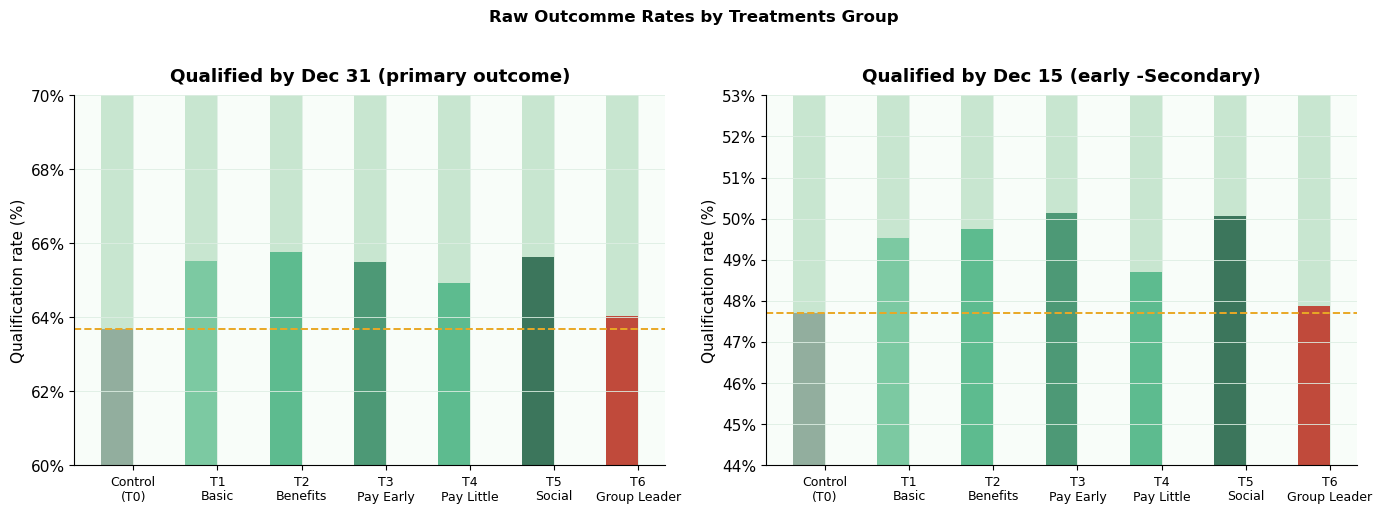

In [97]:
import numpy as np
fig, axes = plt.subplots(1,2, figsize=(14,5))
labels =['Control\n(T0)', 'T1\nBasic', 'T2\nBenefits', 'T3\nPay Early', 'T4\nPay Little', 'T5\nSocial', 'T6\nGroup Leader']
grouping_order= ['0', 'T1', 'T2','T3', 'T4', 'T5', 'T6']
bar_colors = [c['ctrl'], "#74c69d", '#52b788', '#40916c', '#52b788', '#2d6a4f', c['fail']]
x=np.arange(7)
w = 0.38
for ax, outcome, title, ymin, ymax in zip(
        axes, ['Qualified', 'QualifiedDec15'],
        ['Qualified by Dec 31 (primary outcome)', 'Qualified by Dec 15 (early -Secondary)'],
        [60, 44], [70, 53]):
    rf = [rates_full_data.loc[a, outcome]*100 for a in grouping_order]
    rs =[rates_scope.loc[a, outcome]*100 for a in grouping_order]
    ax.bar(x-w/2, rf, w, label='All farmers', color = '#c8e6d0', edgecolor ='none')
    ax.bar(x - w/2, rs, w, label='In-scope Farmers', color = bar_colors, edgecolor ='none', alpha =0.9)
    ctrl_line= rates_scope.loc['0', outcome] *100
    ax.axhline(ctrl_line, color=c['warn'], lw=1.4, ls='--', label=f"Control baseline ({ctrl_line:.1f}%)")
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_ylabel('Qualification rate (%)')
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(ymin, ymax)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

plt.suptitle("Raw Outcomme Rates by Treatments Group", fontweight='bold', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('Raw outcome Rate.png', dpi=150, bbox_inches='tight')
plt.show()
    

## Main Treatment Effects 

We estimate the casual effects of Each SMS group vs the control group using:
1. Simple rate comparison
2. Chi-square test
3. Logistic Regression

In [102]:
ctrl_qualified = df_scope[df_scope['MainTreatment']==0]['Qualified'].mean()
ctr_qual15 =df_scope[df_scope['MainTreatment']==0]['QualifiedDec15'].mean()

results =[]
for group in ['0', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6']:
    sub =df_scope[df_scope['MainTreatment']==group]
    n = len(sub)
    q = sub['Qualified'].mean()
    q15 = sub['QualifiedDec15'].mean()
    lift = q - ctrl_qualified
    l15 =q15 - ctr_qual15
    
    if group == '0':
        p_q, p_q15 = None, None
    else:
        pair =df_scope[df_scope['MainTreatment'].isin(['0', group])]
        ct_q = pd.crosstab(pair['MainTreatment'], pair['Qualified'])
        ct_q15 = pd.crosstab(pair['MainTreatment'], pair['QualifiedDec15'])
        _, p_q, _, _ =stats.chi2_contingency(ct_q)
        _, p_q15, _,_ =stats.chi2_contingency(ct_q15)
        
    results.append({
    'Group': group, "Counts":n,
    "Qual rate": f"{q:.1%}", 'Lift (pp)': f"{lift:.2f}" if group !=0 else "-",
    'p (Dec31)': f"{p_q:.4f}" if p_q else '-',
    "Dec15 rate": f"{q15:.1%}", 'Lift (Dec15)': f"{l15:.2f}" if group !=0 else "-",
    'p (Dec15)': f"{p_q15:.4f}" if p_q15 else '-',
    "Sig?": ('Yes' if (p_q and p_q<0.05) else ("Insignificant" if group !='0' else 'baseline'))
    })

res_df= pd.DataFrame(results).set_index('Group')
print(res_df.to_string())

       Counts Qual rate Lift (pp) p (Dec31) Dec15 rate Lift (Dec15) p (Dec15)           Sig?
Group                                                                                       
0       90710     63.7%       nan         -      47.7%          nan         -       baseline
T1      22676     65.5%       nan    0.0000      49.5%          nan    0.0000            Yes
T2      45349     65.8%       nan    0.0000      49.7%          nan    0.0000            Yes
T3      22753     65.5%       nan    0.0000      50.1%          nan    0.0000            Yes
T4      22609     64.9%       nan    0.0005      48.7%          nan    0.0080            Yes
T5      45327     65.6%       nan    0.0000      50.1%          nan    0.0000            Yes
T6      22734     64.0%       nan    0.3397      47.9%          nan    0.6850  Insignificant


## Visualization of Effects

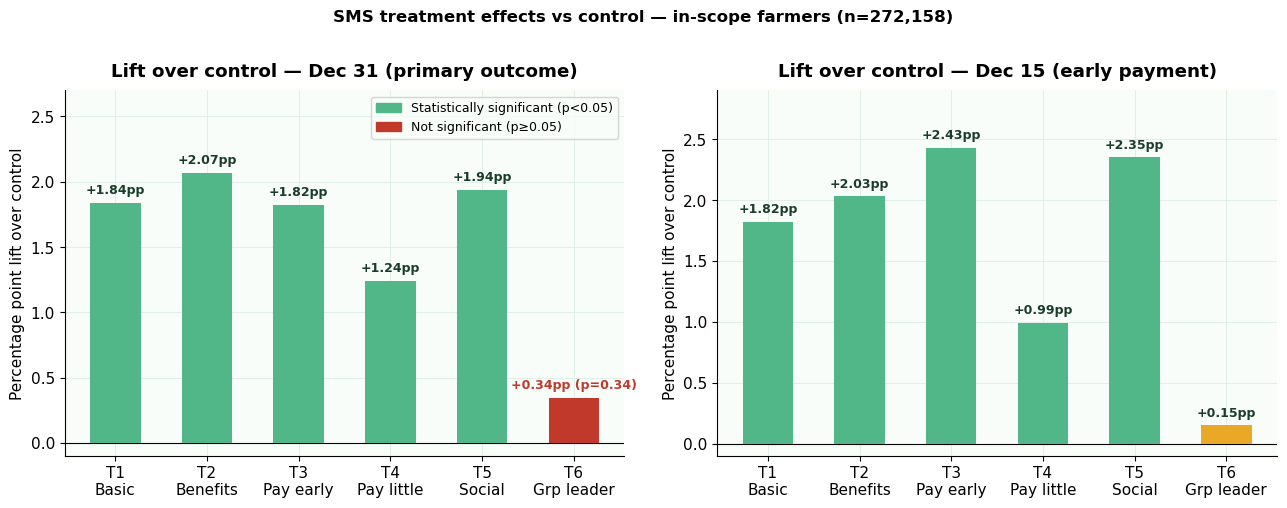

In [110]:
groups   = ["T1\nBasic", "T2\nBenefits", "T3\nPay early",
               "T4\nPay little", "T5\nSocial", "T6\nGrp leader"]
lifts_q    = [1.84, 2.07, 1.82, 1.24, 1.94, 0.34]
lifts_q15  = [1.82, 2.03, 2.43, 0.99, 2.35, 0.15]
pvals_q    = [0.0000, 0.0000, 0.0000, 0.0005, 0.0000, 0.3397]
bar_colors = [c["treat"] if p < 0.05 else c["fail"] for p in pvals_q]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Dec 31 lifts
bars = ax1.bar(groups, lifts_q, color=bar_colors, edgecolor="none",
               width=0.55, zorder=3)
ax1.axhline(0, color="black", lw=0.8)
ax1.set_title("Lift over control — Dec 31 (primary outcome)", fontweight="bold", pad=10)
ax1.set_ylabel("Percentage point lift over control")
ax1.set_ylim(-0.1, 2.7)
for bar, pv, lv in zip(bars, pvals_q, lifts_q):
    label = f"+{lv:.2f}pp" if pv < 0.05 else f"+{lv:.2f}pp (p={pv:.2f})"
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
             label, ha="center", va="bottom", fontsize=9, fontweight="bold",
             color=c["fail"] if pv >= 0.05 else c["best"])

sig_patch  = mpatches.Patch(color=c["treat"], label="Statistically significant (p<0.05)")
fail_patch = mpatches.Patch(color=c["fail"],  label="Not significant (p≥0.05)")
ax1.legend(handles=[sig_patch, fail_patch], fontsize=9)


# Dec 15 lifts
colors15 = [c["treat"] if v > 0.5 else c["warn"] for v in lifts_q15]
bars2 = ax2.bar(groups, lifts_q15, color=colors15, edgecolor="none", width=0.55, zorder=3)
ax2.axhline(0, color="black", lw=0.8)
ax2.set_title("Lift over control — Dec 15 (early payment)", fontweight="bold", pad=10)
ax2.set_ylabel("Percentage point lift over control")
ax2.set_ylim(-0.1, 2.9)
for bar, lv in zip(bars2, lifts_q15):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
             f"+{lv:.2f}pp", ha="center", va="bottom", fontsize=9,
             fontweight="bold", color=c["best"])

plt.suptitle("SMS treatment effects vs control — in-scope farmers (n=272,158)",
             fontweight="bold", y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig("treatment effects.png", dpi=150, bbox_inches="tight")
plt.show()


## Logistic Regression

Chi-Square confirm statistical significance but doesn't control for any covariates. Logistic Regression is run
for clearner estimates, controlling for: Credit amount, seasons, enrolled, group leader status, and 2017 qualification history

In [112]:
#importing linearRegression and StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [114]:
reg_df = df_scope.copy()
for group in ["T1","T2","T3","T4","T5","T6"]:
    reg_df[f"d_{group}"] = (reg_df["MainTreatment"] == group).astype(int)

# Standardise continuous controls
for col in ["TotalCredit","TotalEnrolledSeasons"]:
    mu = reg_df[col].mean()
    sd = reg_df[col].std()
    reg_df[f"{col}_z"] = (reg_df[col] - mu) / sd

feature_cols = ["d_T1","d_T2","d_T3","d_T4","d_T5","d_T6",
                "TotalCredit_z","TotalEnrolledSeasons_z",
                "GroupLeader","Qualified2017"]

X = reg_df[feature_cols].values
y = reg_df["Qualified"].values


scaler = StandardScaler()
lr = LogisticRegression(max_iter=500, solver="lbfgs")
lr.fit(X, y)
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": lr.coef_[0].round(4),
    "Odds Ratio": np.exp(lr.coef_[0]).round(4)
    })
print(" Logistic regression coefficients")
print(coef_df.to_string(index=False))
print("\nNote: Treatment dummies vs control group. Positive coef = higher odds of qualifying.")



 Logistic regression coefficients
               Feature  Coefficient  Odds Ratio
                  d_T1       0.0860      1.0898
                  d_T2       0.0935      1.0980
                  d_T3       0.0834      1.0870
                  d_T4       0.0551      1.0566
                  d_T5       0.0870      1.0909
                  d_T6       0.0201      1.0203
         TotalCredit_z       0.2772      1.3194
TotalEnrolledSeasons_z       0.3712      1.4495
           GroupLeader       0.4591      1.5826
         Qualified2017       0.2686      1.3081

Note: Treatment dummies vs control group. Positive coef = higher odds of qualifying.


## Subgroup and Heterogeneity 

Average treatment effects hide important variation. Here we ask: **who responds most to which message?**
This informs targeting — getting the most qualifiers per SMS naira spent.

### Group Leaders vs Regular Farmers


               Regular farmer  Group leader
MainTreatment                              
0                      0.6268        0.7729
T1                     0.6459        0.7873
T2                     0.6483        0.7833
T3                     0.6463        0.7724
T4                     0.6387        0.7882
T5                     0.6482        0.7655
T6                     0.6301        0.7783


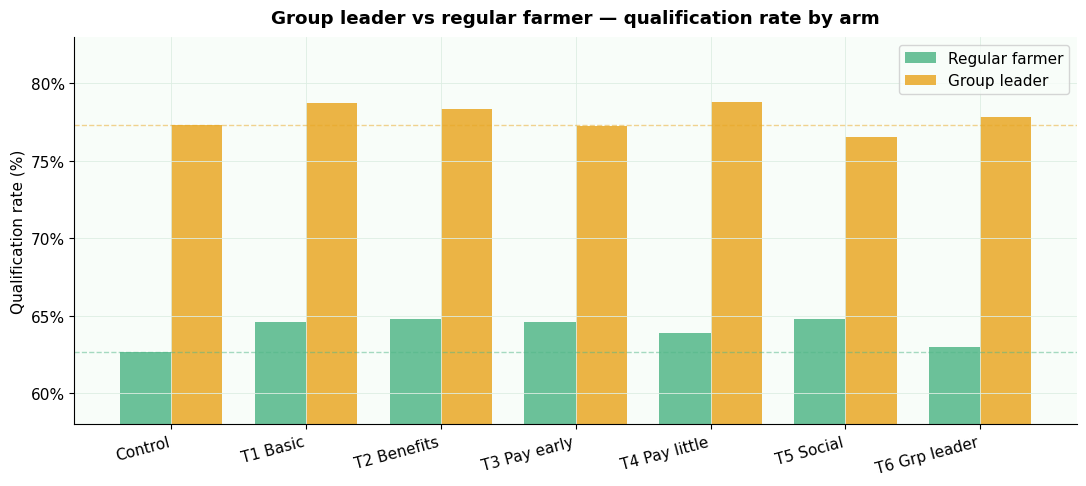

In [116]:
leader_df = df_scope.groupby(["MainTreatment","GroupLeader"])["Qualified"].mean().unstack()
leader_df.columns = ["Regular farmer", "Group leader"]
print(leader_df.round(4).to_string())

arm_labels = ["Control","T1 Basic","T2 Benefits","T3 Pay early",
              "T4 Pay little","T5 Social","T6 Grp leader"]
x = np.arange(7)
w = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, leader_df["Regular farmer"]*100, w,
       label="Regular farmer", color=c["treat"], alpha=0.85, edgecolor="none")
ax.bar(x + w/2, leader_df["Group leader"]*100, w,
       label="Group leader", color=c["warn"], alpha=0.85, edgecolor="none")
ax.set_xticks(x); ax.set_xticklabels(arm_labels, rotation=15, ha="right")
ax.set_ylabel("Qualification rate (%)")
ax.set_ylim(58, 83)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.set_title("Group leader vs regular farmer — qualification rate by arm",
             fontweight="bold", pad=10)
ax.legend()
ax.axhline(leader_df.loc["0","Group leader"]*100, color=c["warn"],
           ls="--", lw=1, alpha=0.5, label="_ctrl leader")
ax.axhline(leader_df.loc["0","Regular farmer"]*100, color=c["treat"],
           ls="--", lw=1, alpha=0.5, label="_ctrl regular")
plt.tight_layout()
plt.savefig("leader subgroup.png", dpi=150, bbox_inches="tight")
plt.show()



In [117]:
print("Insight: Group leaders qualify at ~77-79% regardless of treatment.")
print("SMS adds little for them. Target regular farmers for better ROI.")


Insight: Group leaders qualify at ~77-79% regardless of treatment.
SMS adds little for them. Target regular farmers for better ROI.


## Prior Qualification History

               Did NOT qualify 2017  Qualified 2017
MainTreatment                                      
0                            0.6196          0.7891
T1                           0.6364          0.8213
T2                           0.6390          0.8199
T3                           0.6367          0.8202
T4                           0.6313          0.8093
T5                           0.6386          0.8167
T6                           0.6223          0.8001


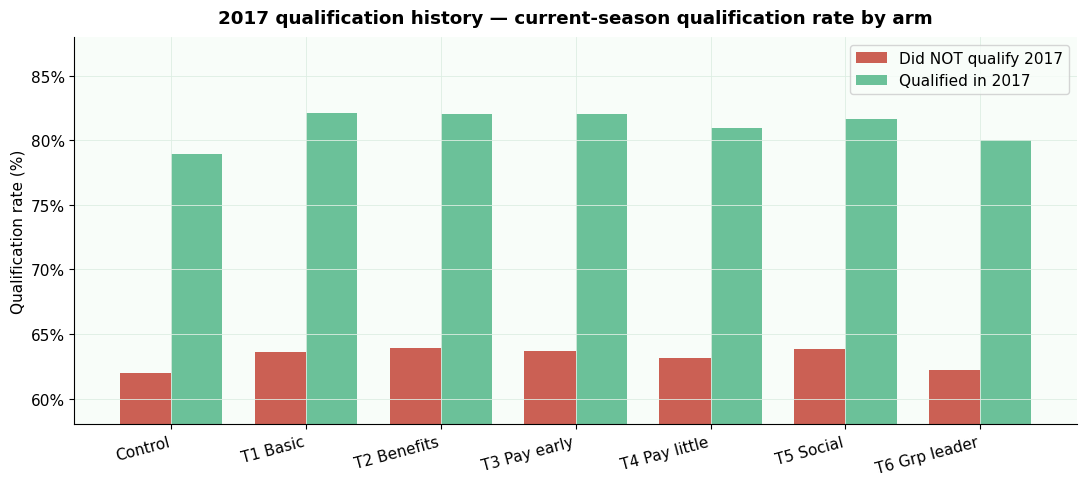

In [118]:
hist_df = df_scope.groupby(["MainTreatment","Qualified2017"])["Qualified"].mean().unstack()
hist_df.columns = ["Did NOT qualify 2017", "Qualified 2017"]
print(hist_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, hist_df["Did NOT qualify 2017"]*100, w,
       label="Did NOT qualify 2017", color=c["fail"], alpha=0.8, edgecolor="none")
ax.bar(x + w/2, hist_df["Qualified 2017"]*100, w,
       label="Qualified in 2017",    color=c["treat"], alpha=0.85, edgecolor="none")
ax.set_xticks(x); ax.set_xticklabels(arm_labels, rotation=15, ha="right")
ax.set_ylabel("Qualification rate (%)")
ax.set_ylim(58, 88)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.set_title("2017 qualification history — current-season qualification rate by arm",
             fontweight="bold", pad=10)
ax.legend()
plt.tight_layout()
plt.savefig("history subgroup.png", dpi=150, bbox_inches="tight")
plt.show()


In [119]:
print("\nInsight: Farmers who failed in 2017 are the highest-value SMS target —")
print("most room to improve, and treatment lifts them by up to 2pp.")


Insight: Farmers who failed in 2017 are the highest-value SMS target —
most room to improve, and treatment lifts them by up to 2pp.


## Credit Amount Quartile

credit_q       Q1 Low     Q2     Q3  Q4 High
MainTreatment                               
0              0.5529 0.6388 0.6477   0.7284
T1             0.5672 0.6619 0.6701   0.7444
T2             0.5613 0.6652 0.6719   0.7553
T3             0.5505 0.6619 0.6812   0.7517
T4             0.5573 0.6645 0.6591   0.7404
T5             0.5652 0.6626 0.6662   0.7506
T6             0.5507 0.6440 0.6578   0.7318


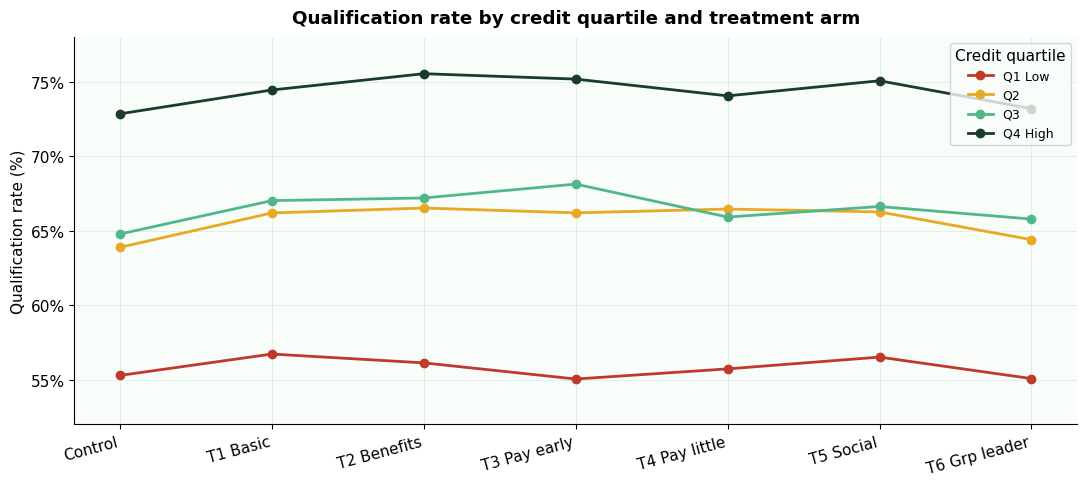

In [120]:
credit_df = df_scope.groupby(["MainTreatment","credit_q"])["Qualified"].mean().unstack()
print(credit_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(11, 5))
colors_q = [c["fail"], c["warn"], c["treat"], c["best"]]
for col, clr in zip(credit_df.columns, colors_q):
    ax.plot(arm_labels, credit_df[col]*100, marker="o", lw=2,
            color=clr, label=col, markersize=6)
ax.set_ylabel("Qualification rate (%)")
ax.set_ylim(52, 78)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.set_title("Qualification rate by credit quartile and treatment arm",
             fontweight="bold", pad=10)
ax.legend(title="Credit quartile", fontsize=9)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("fig6_credit_subgroup.png", dpi=150, bbox_inches="tight")
plt.show()



In [121]:
print("\nInsight: Low-credit farmers (Q1) have both the lowest baseline (~55%)")
print("and the highest proportional gains from messaging.")


Insight: Low-credit farmers (Q1) have both the lowest baseline (~55%)
and the highest proportional gains from messaging.


## Farmers Experience based on Enrollment Season

season_group   New (1)  Mid (2-3)  Veteran (4+)
MainTreatment                                  
0               0.5837     0.7337        0.8319
T1              0.5985     0.7574        0.8669
T2              0.6005     0.7636        0.8592
T3              0.5986     0.7626        0.8565
T4              0.5906     0.7613        0.8487
T5              0.6004     0.7600        0.8547
T6              0.5853     0.7435        0.8406


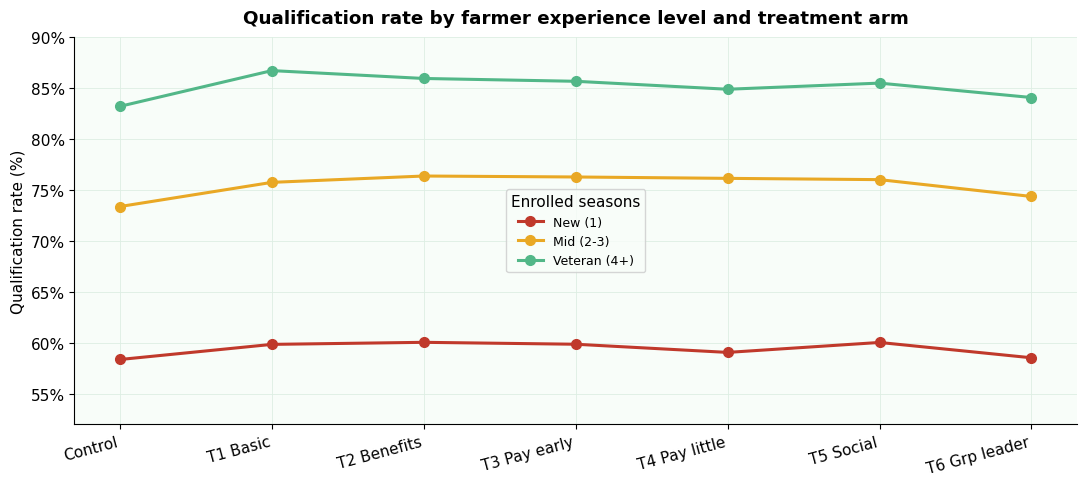

In [122]:
season_df = df_scope.groupby(["MainTreatment","season_group"])["Qualified"].mean().unstack()
season_df = season_df[["New (1)","Mid (2-3)","Veteran (4+)"]]
print(season_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(11, 5))
colors_s = [c["fail"], c["warn"], c["treat"]]
for col, clr in zip(season_df.columns, colors_s):
    ax.plot(arm_labels, season_df[col]*100, marker="o", lw=2.2,
            color=clr, label=col, markersize=7)
ax.set_ylabel("Qualification rate (%)")
ax.set_ylim(52, 90)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.set_title("Qualification rate by farmer experience level and treatment arm",
             fontweight="bold", pad=10)
ax.legend(title="Enrolled seasons", fontsize=9)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("seasons_subgroup.png", dpi=150, bbox_inches="tight")
plt.show()


In [123]:
print("\nInsight: New farmers (season 1) have a 58% baseline — lowest of all groups.")
print("They have the most to gain and should be the primary SMS target.")



Insight: New farmers (season 1) have a 58% baseline — lowest of all groups.
They have the most to gain and should be the primary SMS target.


## Recommendation and Operational Impact

### Summary and Ranking of Findings

In [124]:
summary_data = {
    "Arm":       ["Control","T1 Basic","T2 Benefits","T3 Pay early",
                  "T4 Pay little","T5 Social","T6 Grp leader"],
    "Qual rate": [63.68, 65.53, 65.76, 65.50, 64.92, 65.62, 64.03],
    "Dec31 lift":[0, 1.84, 2.07, 1.82, 1.24, 1.94, 0.34],
    "Dec15 lift":[0, 1.82, 2.03, 2.43, 0.99, 2.35, 0.15],
    "p-value":   ["—","<0.0001","<0.0001","<0.0001","0.0005","<0.0001","0.34"],
    "Verdict":   ["Baseline","Scale","★ Scale","Scale","Consider","★ Scale","RETIRE"],
}
summ_df = pd.DataFrame(summary_data).set_index("Arm")
print(summ_df.to_string())

               Qual rate  Dec31 lift  Dec15 lift  p-value   Verdict
Arm                                                                
Control          63.6800      0.0000      0.0000        —  Baseline
T1 Basic         65.5300      1.8400      1.8200  <0.0001     Scale
T2 Benefits      65.7600      2.0700      2.0300  <0.0001   ★ Scale
T3 Pay early     65.5000      1.8200      2.4300  <0.0001     Scale
T4 Pay little    64.9200      1.2400      0.9900   0.0005  Consider
T5 Social        65.6200      1.9400      2.3500  <0.0001   ★ Scale
T6 Grp leader    64.0300      0.3400      0.1500     0.34    RETIRE


── Projected additional qualifiers if each treatment scaled ──
Arm                 Lift   Extra qualifiers          Extra ₦
--------------------------------------------------------------
T1 Basic           1.84pp              3,338        1,669,000
T2 Benefits        2.07pp              3,755        1,877,500
T3 Pay early       1.82pp              3,302        1,651,000
T4 Pay little      1.24pp              2,249        1,124,500
T5 Social          1.94pp              3,520        1,760,000


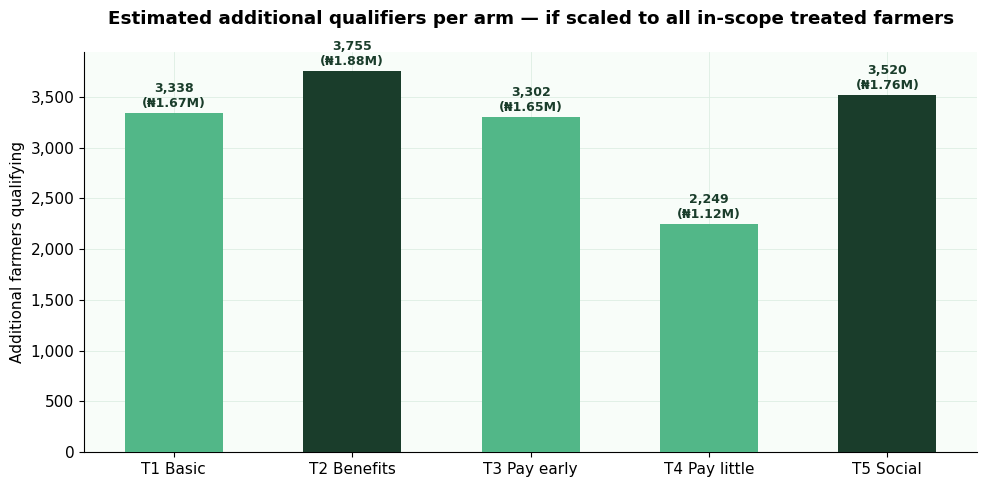

In [127]:
N_TREATED_SCOPE = 181_448       
CTRL_RATE       = 0.6368
NGN_PER_FARMER  = 500           

print("── Projected additional qualifiers if each treatment scaled ──")
print(f"{'Arm':<15} {'Lift':>8} {'Extra qualifiers':>18} {'Extra ₦':>16}")
print("-" * 62)

proj = []
for arm, lift in [("T1 Basic",1.84),("T2 Benefits",2.07),("T3 Pay early",1.82),
                  ("T4 Pay little",1.24),("T5 Social",1.94)]:
    extra = int(N_TREATED_SCOPE * lift/100)
    naira = extra * NGN_PER_FARMER
    proj.append((arm, lift, extra, naira))
    print(f"{arm:<15} {lift:>7.2f}pp {extra:>18,} {naira:>16,}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
arms_p  = [p[0] for p in proj]
extras  = [p[2] for p in proj]
colors_p = [c["best"] if "Benefits" in a or "Social" in a else c["treat"] for a in arms_p]
bars = ax.bar(arms_p, extras, color=colors_p, edgecolor="none",
              width=0.55, zorder=3)
ax.set_title("Estimated additional qualifiers per arm — if scaled to all in-scope treated farmers",
             fontweight="bold", pad=20)
ax.set_ylabel("Additional farmers qualifying")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
for bar, p in zip(bars, proj):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            f"{p[2]:,}\n(₦{p[3]/1e6:.2f}M)", ha="center", va="bottom",
            fontsize=9, fontweight="bold", color=c["best"])
plt.tight_layout()
plt.savefig("scale projection.png", dpi=150, bbox_inches="tight")
plt.show()